In [23]:
import numpy as np
import torch
import os
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [29]:
# Load the data from the specified directory
X_train = np.load('../ProcessedInputData/single_X_train.npy')
Y_train = np.load('../ProcessedInputData/single_y_train.npy')
X_val = np.load('../ProcessedInputData/single_X_val.npy')
Y_val = np.load('../ProcessedInputData/single_y_val.npy')


# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.long)

# Create a DataLoader for batching
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # don't shuffle for LTSM?
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

sanity_dataset = TensorDataset(X_train_tensor[:20], Y_train_tensor[:20]) # take just a few elements
sanity_loader = DataLoader(sanity_dataset, batch_size=5, shuffle=False)

In [ ]:
# Print the first few elements of the tensors
print("First few elements of Y_train_tensor:")
print(Y_train_tensor.size())
print(Y_train_tensor[:30])  # Print first 10 elements

print("First few elements of X_train_tensor:")
print(X_train_tensor.size())
# print(X_train_tensor[:3])  # Print first 3 elements

# each input is 5x90x1 matrix
# 5 bc there are 5 eeg channels recordings per sample,
# 90 bc i did fourier transform and binned it into 90 different bins from 0.5 to 40 Hz (relevant frequencies for EEG)
# the 1 was added just to be the dimension of picture style for CNN so its like black and white

# Update: now 90x1 where each channel is separate datapoint

print("Val tensors:")
print(Y_val_tensor.size())
print(X_val_tensor.size())

# original size [3153, 5, 90, 1]
# current size  [15768, 90, 1]

First few elements of Y_train_tensor:
torch.Size([15768])
tensor([1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 1, 1, 0, 0])
First few elements of X_train_tensor:
torch.Size([15768, 90, 1])
Val tensors:
torch.Size([1971])
torch.Size([1971, 90, 1])


In [ ]:
# Conv2d expecs (batch size, channels, height, width) 4D input

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class CNN1D(nn.Module):
    def __init__(self):
        super(CNN1D, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # 1D convolution
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)  # 1D max pooling
        self.relu = nn.ReLU()
        
        # Compute FC input size dynamically
        self._to_linear = None
        self._compute_linear_input_size()
        
        self.fc1 = nn.Linear(self._to_linear, 64)
        self.fc2 = nn.Linear(64, 1)  # Single output
        
    def _compute_linear_input_size(self):
        with torch.no_grad():
            x = torch.zeros(1, 1, 90)  # Dummy input with shape (batch_size, channels, frequency bins)
            x = self.pool(self.relu(self.conv1(x)))
            x = self.pool(self.relu(self.conv2(x)))
            self._to_linear = x.numel()  # Flatten size calculation

    def forward(self, x):
        x = x.view(x.size(0), 1, 90)  # Ensure correct input shape (batch, 1, 90)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)  # No activation (BCEWithLogitsLoss expects raw logits)
        return x

# Xavier Initialization Function
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# Training Function
def train_model(model, train_loader, epochs=10):
    torch.manual_seed(1000)
    model.train()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0
        
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            labels = labels.view(-1, 1).float()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            predicted = torch.round(torch.sigmoid(outputs))  # Convert logits to binary predictions
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        
        avg_loss = running_loss / len(train_loader)
        accuracy = 100 * correct / total
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

# Initialize Model
cnn_model = CNN1D()
cnn_model.apply(init_weights)

# Train Model
train_model(model=cnn_model, train_loader=sanity_loader, epochs=300)


Epoch [1/10]
Train Loss: 9.4570 | Train Accuracy: 51.13%
Val Loss: 8.3023 | Val Accuracy: 49.72%

Epoch [2/10]
Train Loss: 5.9332 | Train Accuracy: 50.45%
Val Loss: 1.3354 | Val Accuracy: 49.97%

Epoch [3/10]
Train Loss: 1.2545 | Train Accuracy: 50.20%
Val Loss: 0.6950 | Val Accuracy: 50.03%

Epoch [4/10]
Train Loss: 0.6933 | Train Accuracy: 50.10%
Val Loss: 0.6946 | Val Accuracy: 50.33%

Epoch [5/10]
Train Loss: 0.6920 | Train Accuracy: 51.65%
Val Loss: 0.6934 | Val Accuracy: 51.40%

Epoch [6/10]
Train Loss: 0.6906 | Train Accuracy: 52.22%
Val Loss: 0.6911 | Val Accuracy: 52.05%

Epoch [7/10]
Train Loss: 0.6893 | Train Accuracy: 52.57%
Val Loss: 0.6908 | Val Accuracy: 51.95%

Epoch [8/10]
Train Loss: 0.6887 | Train Accuracy: 52.70%
Val Loss: 0.6913 | Val Accuracy: 51.60%

Epoch [9/10]
Train Loss: 0.6879 | Train Accuracy: 52.69%
Val Loss: 0.6904 | Val Accuracy: 51.80%

Epoch [10/10]
Train Loss: 0.6877 | Train Accuracy: 52.71%
Val Loss: 0.6904 | Val Accuracy: 51.75%

Loaded best model w

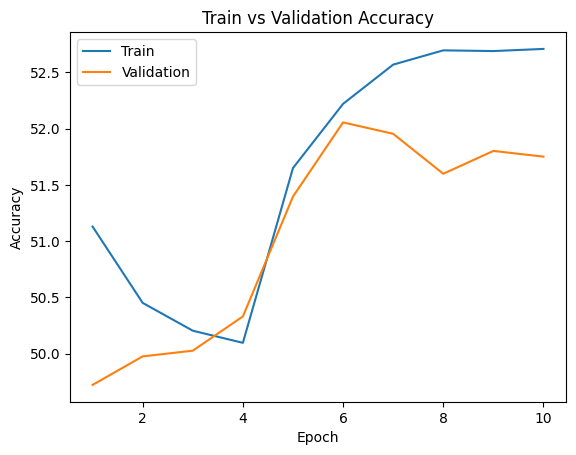

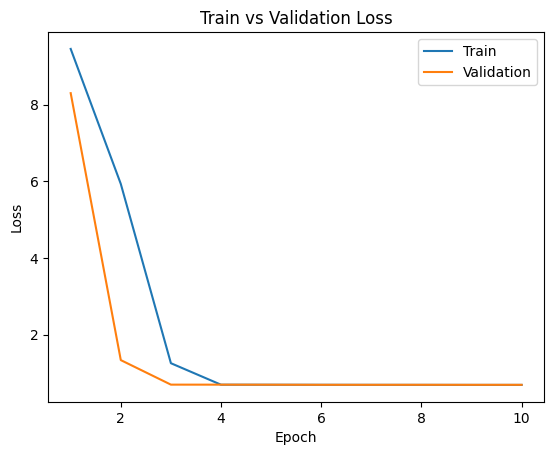

In [52]:
def train_and_validate(model, train_loader, val_loader, epochs=100, patience=20, print_every=5):
    torch.manual_seed(1000)
    model.train()
    criterion = nn.BCEWithLogitsLoss()  
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

    best_val_loss = float("inf")  # Initialize best validation loss
    patience_counter = 0  # Counts epochs without improvement
    best_model_state = None  # Store best model weights

    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        # Training loop
        model.train()
        for batch_idx, (inputs, labels) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(inputs)
            labels = labels.view(-1, 1).float()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            predicted = torch.round(torch.sigmoid(outputs))  
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            # Print only for the first batch (batch_idx == 0)
            '''
            if batch_idx == 0 and epoch == epochs-1:
                print(f"Epoch {epoch+1} training (First Batch Only)")
                print(inputs.size())
                print("Inputs: ", inputs[:3, :3, 0])  # First 3 samples, first 3 frequency bins, single channel
                print("Outputs: ", outputs[:3])
                print("Predicted: ", predicted[:3])
                print("Labels: ", labels[:3])
            '''

        avg_train_loss = running_loss / len(train_loader)
        train_accuracy = 100 * correct / total

        # Validation loop (no gradient updates)
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch_idx, (inputs, labels) in enumerate(val_loader):
                outputs = model(inputs)
                labels = labels.view(-1, 1).float()
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                predicted = torch.round(torch.sigmoid(outputs))
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                # Print only for the first batch (batch_idx == 0)
                '''
                if batch_idx == 0 and epoch == epochs-1:
                    print(f"Validation (First Batch Only)")
                    print("Inputs: ", inputs[:3, :3, 0])  # First 3 samples, first 3 frequency bins, single channel
                    print("Outputs: ", outputs[:3])
                    print("Predicted: ", predicted[:3])
                    print("Labels: ", labels[:3])
                '''
                #print("Predicted: ", predicted[:])

        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        if (epoch % print_every == 0):
            # Print results
            print(f"Epoch [{epoch+1}/{epochs}]")
            print(f"Train Loss: {avg_train_loss:.4f} | Train Accuracy: {train_accuracy:.2f}%")
            print(f"Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%\n")

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Early Stopping Logic
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss  # Update best loss
            patience_counter = 0  # Reset counter
            best_model_state = model.state_dict()  # Save best model
        else:
            patience_counter += 1  # Increment counter

        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break  # Stop training

    # Load best model before exiting
    if best_model_state:
        model.load_state_dict(best_model_state)
        print("Loaded best model with lowest validation loss.")

    # Plot the curves
    import matplotlib.pyplot as plt
    plt.title("Train vs Validation Accuracy")
    n = len(train_accuracies) # number of epochs
    plt.plot(range(1,n+1), train_accuracies, label="Train")
    plt.plot(range(1,n+1), val_accuracies, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend(loc='best')
    plt.show()
    plt.title("Train vs Validation Loss")
    plt.plot(range(1,n+1), train_losses, label="Train")
    plt.plot(range(1,n+1), val_losses, label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend(loc='best')
    plt.show()

    return model  # Return best model

# Xavier Initialization Function
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv1d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

# My model
class AntoineNet(nn.Module):
    def __init__(self):
        super(AntoineNet, self).__init__()

        # Convolutional Layers (Feature Extraction)
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)

        # Fully Connected Layers
        self.fc1 = nn.Linear(32 * 90, 32)  # Assuming the input has a length of 90 (the number of frequency bins)
        self.fc2 = nn.Linear(32, 1)  # Output layer

        # Regularization
        self.leaky_relu = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = x.view(x.size(0), 1, 90)  # Ensure shape (batch, 1, 90)

        # Pass through Conv Layers with LeakyReLU activation
        x = self.leaky_relu(self.conv1(x))
        x = self.leaky_relu(self.conv2(x))  # Keep full sequence

        # Flatten the output for the fully connected layer
        x = x.view(x.size(0), -1)  # Flatten the output (batch_size, 32 * 90)

        # Fully Connected Layers
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # No activation (BCEWithLogitsLoss expects raw logits)

        return x


# Initialize Model
my_model = AntoineNet()
my_model.apply(init_weights)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # don't shuffle for LTSM?
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Train Model
#my_model = train_and_validate(model=my_model, train_loader=sanity_loader, val_loader=sanity_loader, epochs=100, patience=100)
my_model = train_and_validate(model=my_model, train_loader=train_loader, val_loader=val_loader, epochs=10, patience=4, print_every=1)